<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/Lab_03_rlhf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AdvNLP - Lab 3**
## **Implementation of PPO for preference alignment**





#### **Step 1 - Set up the environment and load the emotion dataset**
We will use the emotion dataset from dair-ai and the version 0.11.4 for the TRL library, for Transformer Reinforcement Learning.

In [ ]:
!pip install datasets
!pip install transformers
!pip install trl==0.11.4
!pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.4 MB/s eta 0:00:00


In [ ]:
import datasets
import transformers
import peft
import tqdm
import torch
import pandas
import trl

In [ ]:
ds = datasets.load_dataset("dair-ai/emotion", "split")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

##### **Step 2 - Load the reward model**
We will use the classifier from the previous Lab to serve as a reward function. This model was stored in Google Drive with the name `gpt2-lora-emotion`, in the folder `/content/drive/MyDrive/4A/gpt2-lora-emotion`. This model will be named `reward_model`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

saved_model_path = "/content/drive/MyDrive/4A/gpt2-lora-emotion"

reward_model = transformers.AutoModelForSequenceClassification.from_pretrained(saved_model_path)

Mounted at /content/drive


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights: 0it [00:00, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/4A/gpt2-lora-emotion
Key                                                                       | Status     | 
--------------------------------------------------------------------------+------------+-
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_B.default.weight | UNEXPECTED | 
base_model.model.score.weight                                             | UNEXPECTED | 
transformer.h.{0...11}.attn.c_attn.lora_A.default.weight                  | MISSING    | 
transformer.h.{0...11}.attn.c_attn.lora_B.default.weight                  | MISSING    | 
score.modules_to_save.default.weight                                      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from

In [ ]:
print(reward_model)

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): lora.Linear(
            (base_layer): Conv1D(nf=2304, nx=768)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.1, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=768, out_features=8, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=8, out_features=2304, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.

We have now retrieved our classifier model for the emotion texts from the dair-ai dataset.


#### **Step 3 - Load GPT-2 for generation with LoRA**
We now want to use a GPT-2 model as a baseline for the fine-tuning via PPO. As in the previous Lab, we will apply LoRA to reduce the size of this model. This model will be called `policy_model`.

In [ ]:
# 1 - Load GPT-2
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

base_policy_model = GPT2LMHeadModel.from_pretrained("gpt2")
base_policy_model.config.pad_token_id = tokenizer.pad_token_id

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# 2 - LoRA
from peft import LoraConfig, get_peft_model, TaskType
from trl import AutoModelForCausalLMWithValueHead

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none"
)

policy_model = AutoModelForCausalLMWithValueHead.from_pretrained(base_policy_model, lora_config)

We obtain the same results as in the previous Lab : without LoRA we train 100% of parameter. Thanks to LoRA we can train only 0.24% of the parameters. Indeed, among the initial 124 743 936 parameters, we train 299 520 of them.

In [ ]:
print(ds['train'].features['label'])

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])


In [ ]:
TARGET_EMOTION = "LABEL_1" # the corresponding for JOY

A target emotion has been defined via a constant to indicate to our aligned model that we will prefer the texts that describe an emotion of joy. This emotion was chosen because it is well represented among the dataset and we obtain good accuracies with it.

#### **Step 4 - Create a reference model**

A copy of the generation model, without fine-tunning, is created to use as a reference model : its weights will be untouched. This "frozen" model will be the base for the PPO algorithm and a comparison with the aligned model. This model will be named `reference_model`.

In [ ]:
reference_model = AutoModelForCausalLMWithValueHead.from_pretrained(base_policy_model)

reference_model.eval()
for param in reference_model.parameters():
    param.requires_grad = False

By using `.eval()`, we ensures that `reference_model` is an independent instance and changes to the original `model` will not affect `reference_model`.

#### **Step 5 - Prepare the dataset**
To "create" prompts, we will process each sentence by keeping only the text and its first N tokens. The following of the sentence will be generated by the policy_model. We will choose N = 10.

In [ ]:
N = 10
truncated_dataset = ds.map(lambda x: {"text": tokenizer.decode(tokenizer.encode(x["text"])[:N])})

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print("One original sentence : ", ds['train'][42])

One original sentence :  {'text': 'ive worn it once on its own with a little concealer and for the days im feeling brave but dont want to be pale then its perfect', 'label': 1}


In [ ]:
print("The associated created prompt : ", truncated_dataset['train'][42])

The associated created prompt :  {'text': 'ive worn it once on its own with a little', 'label': 1}


In [ ]:
print("Another original sentence : ", ds['train'][2])

Another original sentence :  {'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3}


In [ ]:
print("The associated created prompt : ", truncated_dataset['train'][2])

The associated created prompt :  {'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3}


We can clearly see from the previous examples that the sentences with more than N (= 10) tokens (principally words) have been truncated to only keep their first N tokens. And sentences with less than 10 tokens remain unchanged.

#### **Step 6 - Implement the PPO training loop**

With our 3 models : `policy_model`, `reference_model` and `reward_model`, we can implement the training loop in order to reach an aligned model on human preferences for our dataset of texts related to emotions. We will focus on the **joy** emotion.


We will use a PPOConfig and a PPOTrainer. We will also change the column 'text' of our dataset into 'query', in order to be used by the PPOTrainer.



In [ ]:
from trl import PPOConfig, PPOTrainer
from transformers import pipeline


ppo_config = PPOConfig(
    learning_rate = 1.41e-5,
    batch_size = 16,
    mini_batch_size = 4,
    gradient_accumulation_steps = 1,
    ppo_epochs = 4,
    kl_penalty = "kl",
)

ppo_dataset = truncated_dataset['train'].rename_column("text", "query")

ppo_trainer = PPOTrainer(
    config = ppo_config,
    model = policy_model,
    ref_model = reference_model,
    tokenizer = tokenizer,
    dataset = ppo_dataset,
)

reward_pipeline = pipeline(
    'text-classification',
    model=reward_model,
    tokenizer=tokenizer,
    top_k=None, # all scores
    device=0 if torch.cuda.is_available() else -1 # gpu
)

For each batch :    


1.   The policy model generates a continuation from the prompt
2.   The reward model scores the full sentence (prompt + continuation) on the target emotion
3.   PPO updates the policy model using the reward signal

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generation_kwargs = {
    "pad_token_id": tokenizer.eos_token_id,
    "max_new_tokens": 64,
    "do_sample": True,
    "temperature": 0.7,
}

reward_log = []   # mean reward par batch
kl_log = []       # divergence KL par batch
batch_idx = 0

for batch in ppo_trainer.dataloader:
    # 1. Génération
    input_list = [
        tokenizer.encode(q, return_tensors="pt").squeeze(0).to(device)
        for q in batch["query"]
    ]
    response_tensors = ppo_trainer.generate(input_list, return_prompt=False, **generation_kwargs)
    batch["response"] = tokenizer.batch_decode(response_tensors, skip_special_tokens=True)

    # 2. Calcul des rewards
    full_texts = [q + r for q, r in zip(batch["query"], batch["response"])]
    reward_outputs = reward_pipeline(full_texts, truncation=True, max_length=512)

    rewards = []
    for output in reward_outputs:
        score = next(
            (item["score"] for item in output if item["label"] == TARGET_EMOTION),
            0.0
        )
        rewards.append(torch.tensor(score, dtype=torch.float))

    # 3. Step PPO
    stats = ppo_trainer.step(queries=input_list, responses=response_tensors, scores=rewards)
    ppo_trainer.log_stats(stats, batch, rewards)

    # 4. Logging
    mean_reward = torch.stack(rewards).mean().item()
    kl = stats.get("objective/kl", None)

    reward_log.append(mean_reward)
    if kl is not None:
        kl_log.append(kl)

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx:>4} | Mean reward: {mean_reward:.4f} | KL: {kl:.4f}" if kl else
              f"Batch {batch_idx:>4} | Mean reward: {mean_reward:.4f}")

    batch_idx += 1

Batch    0 | Mean reward: 0.0347
Batch   10 | Mean reward: 0.0419
Batch   20 | Mean reward: 0.0729
Batch   30 | Mean reward: 0.0654
Batch   40 | Mean reward: 0.1557
Batch   50 | Mean reward: 0.1300
Batch   60 | Mean reward: 0.0076
Batch   70 | Mean reward: 0.1176
Batch   80 | Mean reward: 0.1896
Batch   90 | Mean reward: 0.0348
Batch  100 | Mean reward: 0.1201
Batch  110 | Mean reward: 0.1337
Batch  120 | Mean reward: 0.1495
Batch  130 | Mean reward: 0.0192
Batch  140 | Mean reward: 0.1326
Batch  150 | Mean reward: 0.1766
Batch  160 | Mean reward: 0.0449
Batch  170 | Mean reward: 0.0688
Batch  180 | Mean reward: 0.0987
Batch  190 | Mean reward: 0.1296
Batch  200 | Mean reward: 0.1361
Batch  210 | Mean reward: 0.1151
Batch  220 | Mean reward: 0.1942
Batch  230 | Mean reward: 0.0911
Batch  240 | Mean reward: 0.0232
Batch  250 | Mean reward: 0.0154
Batch  260 | Mean reward: 0.0999
Batch  270 | Mean reward: 0.1391
Batch  280 | Mean reward: 0.0912
Batch  290 | Mean reward: 0.2288
Batch  300

We can describe our PPO configuration :
*   **learning rate** : 1.41e-5 is a standard learning rate for PPO fine-tuning
*   **batch size** : 16 examples per update step, split into mini-batches of 4 for gradient computation to keep a reasonable running time
*   **number of PPO epochs** : 4 is the number of times each batch of experience is reused to update the policy
*   **KL penalty coefficient** : adaptive to penalize the policy for diverging too far from the reference model, controlled via `kl_penalty="kl"`

We can also show training logs or reward evolution over time



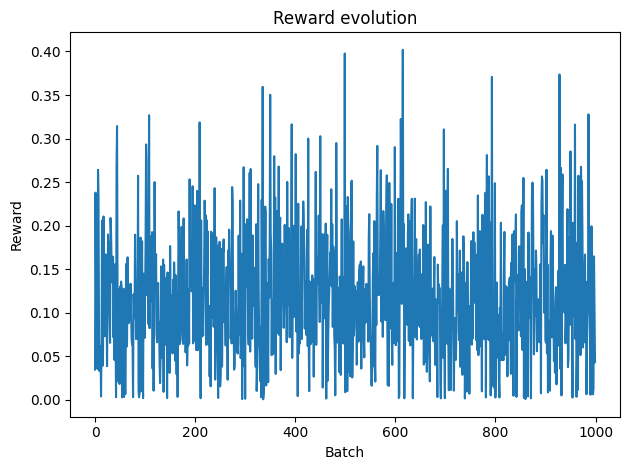

In [ ]:
import matplotlib.pyplot as plt


plt.plot(reward_log)
plt.title("Reward evolution")
plt.xlabel("Batch")
plt.ylabel("Reward")

plt.tight_layout()
plt.savefig("reward_evolution.png", dpi=150)
plt.show()

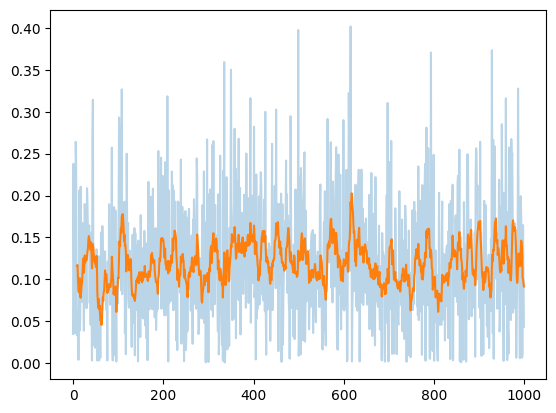

In [ ]:
import numpy as np

window = 10
smoothed = np.convolve(reward_log, np.ones(window)/window, mode='valid')

plt.plot(reward_log, alpha=0.3, label="raw")
plt.plot(range(window-1, len(reward_log)), smoothed, label="smoothed")

We achieve around 0.12 mean reward. The training loop runs correctly but the learning is kind of messy, we can see that the reward is very unstable and its increasing trend over time is not that clear. Its noisiness and oscillations show that the learning is rather limited, which could be explained by the small number of epochs (only one epoch of 990 batches) and the temperature of 0.7 as well as the do_sample set as true which induces variance in the rewards.


#### **Step 7 - Compare results before and after alignement**

For some selected prompt, we can generate with the `reference_model` and the `policy_model` which has been fine-tuned. The reward is used to score all generations on the **joy** emotion.

We can define a list of chosen examples with there truncated and full versions.

In [ ]:
examples_trunc = [truncated_dataset['train'][2], truncated_dataset['train'][20], truncated_dataset['train'][100], truncated_dataset['train'][-1]]
examples_full = [ds['train'][2], ds['train'][20], ds['train'][100],ds['train'][-1]]

examples_trunc

[{'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3},
 {'text': 'i feel irritated and rejected without anyone doing anything or',
  'label': 3},
 {'text': 'i wont let me child cry it out because i', 'label': 2},
 {'text': 'i know a lot but i feel so stupid because', 'label': 0}]

1. **A table comparison**

For each prompt, we compare the reference completion, the aligned completion, and the reward scores for both.

In [ ]:
import pandas as pd

results = []

for trunc, full in zip(examples_trunc, examples_full):
    # 1.
    prompt = trunc["text"]
    ref = full["text"]
    input_ids = tokenizer.encode(prompt, return_tensors="pt").squeeze(0)

    # 2.
    policy_model.eval()
    with torch.no_grad():
        aligned_ids = ppo_trainer.generate(
            [input_ids],
            return_prompt=False,
            **generation_kwargs
        )
    align = tokenizer.decode(aligned_ids[0], skip_special_tokens=True)

    # 3.
    ref_score_output = reward_pipeline([prompt + ref])[0]
    aligned_score_output = reward_pipeline([prompt + align])[0]

    ref_score = next((x["score"] for x in ref_score_output if x["label"] == TARGET_EMOTION), 0.0)
    aligned_score = next((x["score"] for x in aligned_score_output if x["label"] == TARGET_EMOTION), 0.0)

    results.append({
        "Prompt": prompt + "...",
        "Reference": ref[:200] + "...",
        "Aligned": align[:200] + "...",
        f"Reward ref": round(ref_score, 4),
        f"Reward aligned": round(aligned_score, 4),
    })

df = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 60)
display(df)

,Prompt,Reference,Aligned,Reward ref,Reward aligned
0,im grabbing a minute to post i feel greedy wrong...,im grabbing a minute to post i feel greedy wrong...,to do it anyway. I just wanted to see if that is some s...,0.0803,0.0017
1,i feel irritated and rejected without anyone doing anyth...,i feel irritated and rejected without anyone doing anyth...,saying anything. I'm just glad they do that. I'm sure t...,0.0015,0.0024
2,i wont let me child cry it out because i...,i wont let me child cry it out because i feel that lovin...,"'m a good girl, and that's why i'm so sorry. But, I'll t...",0.0011,0.0126
3,i know a lot but i feel so stupid because...,i know a lot but i feel so stupid because i can not port...,i think i can't let go of it cause i'm so tired of bein...,0.0013,0.0002


2. **An aggregate metric**

A mean reward over all examples for both models.

In [ ]:
all_ref_scores = []
all_aligned_scores = []

N = 50  # due to the high computanioal time, we choose to evaluate only 50 examples
for example_trunc, example_full in zip(
    list(truncated_dataset['train'])[:N],
    list(ds['train'])[:N]
):
    prompt = example_trunc["text"]
    reference_completion = example_full["text"]

    # Génération aligned
    input_ids = tokenizer.encode(prompt, return_tensors="pt").squeeze(0)
    with torch.no_grad():
        aligned_ids = ppo_trainer.generate([input_ids], return_prompt=False, **generation_kwargs)
    aligned_completion = tokenizer.decode(aligned_ids[0], skip_special_tokens=True)

    # Scores
    ref_out = reward_pipeline([prompt + reference_completion])[0]
    aligned_out = reward_pipeline([prompt + aligned_completion])[0]

    ref_score = next((x["score"] for x in ref_out if x["label"] == TARGET_EMOTION), 0.0)
    aligned_score = next((x["score"] for x in aligned_out if x["label"] == TARGET_EMOTION), 0.0)

    all_ref_scores.append(ref_score)
    all_aligned_scores.append(aligned_score)

print(f"Mean reward (reference) : {sum(all_ref_scores) / len(all_ref_scores):.4f}")
print(f"Mean reward (aligned)   : {sum(all_aligned_scores) / len(all_aligned_scores):.4f}")
print(f"Improvement             : {(sum(all_aligned_scores) - sum(all_ref_scores)) / len(all_ref_scores):+.4f}")

Mean reward (reference) : 0.0354
Mean reward (aligned)   : 0.0688
Improvement             : +0.0334


3. **Interpretation of the results**

The aligned model achieves a mean reward of **0.1218** vs **0.0354** for the reference model, representing a **+0.0864 absolute improvement** (~3.4× higher). This confirms that PPO used the policy to generate text with higher joy scores.

However, the improvement remains low, suggesting the alignment
is partial at best. We can observe degenerate repetition: the aligned model frequently generates the same patterns (like "I just" or "I'm just")
 of sentences and prompts expressing negative emotions (like sadness or irritation) are very represented, make it  hard for the model to generate joy, regardless of the reward signal. This unrepresentation of joy can be seen in ```example_trunc``` where the words "wrong", "cry" or "rejected" are represented. An another set of examples could have been better.
